## Hockey Standings Web Scraping Project

In [12]:
"""
  Title: Hockey Standings Web Scraper
  Name: Amidu Dabor
  Date: 18 May 2025
  Description: An object-oriented implementation of a web scraper designed to extract 
               hockey standings data from a website and save it as a CSV file.
               Includes data inspection, analysis, and visualization capabilities.
"""

from typing import Optional, Dict, Any, Tuple
import requests
from bs4 import BeautifulSoup, Tag
import pandas as pd
import numpy as np
import logging
import time
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate


class HockeyScraper:
    """
    A class for scraping hockey standings data from websites.
    
    This class provides methods to retrieve, parse, and process hockey standings
    data from web sources in an object-oriented manner with comprehensive
    inspection capabilities at each stage of the scraping process.
    """
    
    def __init__(self, 
                 url: str, 
                 output_dir: str = "./output", 
                 log_level: int = logging.INFO, 
                 verbose: bool = True):
        """
        Initialize the HockeyScraper with configuration parameters.
        
        Args:
            url (str): The URL to scrape data from
            output_dir (str): Directory to save output files
            log_level (int): Logging level (from logging module)
            verbose (bool): Whether to display detailed information during execution
        """
        self.url = url
        self.output_dir = output_dir
        self.verbose = verbose
        self.headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
        }
        
        # Initialize variables for storing scraped data
        self.soup = None
        self.html_content = None
        self.data_frame = None
        self.raw_table_data = None
        self.table_headers = None
        self.table_rows = None
        self.analysis_results = {}
        
        # Set up logging
        self._setup_logging(log_level)
        
        # Create output directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)
        
        self.logger.info(f"HockeyScraper initialized with URL: {url}")
    
    def _setup_logging(self, log_level: int) -> None:
        """
        Set up logging configuration.
        
        Args:
            log_level (int): Logging level
        """
        self.logger = logging.getLogger("HockeyScraper")
        self.logger.setLevel(log_level)
        
        # Create handlers if they don't exist
        if not self.logger.handlers:
            # Create log directory if it doesn't exist
            log_dir = "./logs"
            os.makedirs(log_dir, exist_ok=True)
            
            # File handler with timestamp to avoid overwriting
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            log_file = os.path.join(log_dir, f"hockey_scraper_{timestamp}.log")
            file_handler = logging.FileHandler(log_file)
            file_handler.setLevel(log_level)
            
            # Console handler
            console_handler = logging.StreamHandler()
            console_handler.setLevel(log_level)
            
            # Create formatter
            formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
            file_handler.setFormatter(formatter)
            console_handler.setFormatter(formatter)
            
            # Add handlers to logger
            self.logger.addHandler(file_handler)
            self.logger.addHandler(console_handler)
            
            self.logger.info(f"Logging initialized at level {logging.getLevelName(log_level)}")
            self.logger.info(f"Log file: {log_file}")
    
    def fetch_page(self, max_retries: int = 3, delay: int = 2) -> bool:
        """
        Fetch the webpage content from the URL.
        
        Args:
            max_retries (int): Maximum number of retry attempts
            delay (int): Delay between retries in seconds
            
        Returns:
            bool: True if fetch was successful, False otherwise
        """
        self.logger.info(f"Fetching page content from {self.url}")
        
        for attempt in range(max_retries):
            try:
                response = requests.get(self.url, headers=self.headers, timeout=10)
                response.raise_for_status()
                
                # Store the HTML content
                self.html_content = response.text
                
                # Parse the HTML content
                self.soup = BeautifulSoup(self.html_content, 'html.parser')
                self.logger.info(f"Successfully fetched and parsed page content - Status code: {response.status_code}")
                
                if self.verbose:
                    print(f"Successfully fetched page from {self.url}")
                    print(f"   Status code: {response.status_code}")
                    print(f"   Content size: {len(self.html_content)/1024:.1f} KB")
                
                return True
                
            except requests.exceptions.RequestException as e:
                self.logger.warning(f"Attempt {attempt + 1}/{max_retries} failed: {str(e)}")
                
                if self.verbose:
                    print(f"Attempt {attempt + 1}/{max_retries} failed: {str(e)}")
                
                if attempt < max_retries - 1:
                    self.logger.info(f"Waiting {delay} seconds before retrying...")
                    
                    if self.verbose:
                        print(f"   Waiting {delay} seconds before retrying...")
                    
                    time.sleep(delay)
                else:
                    self.logger.error(f"Failed to fetch page after {max_retries} attempts")
                    
                    if self.verbose:
                        print(f"Failed to fetch page after {max_retries} attempts")
                    
                    return False
        
        return False
    
    def inspect_html(self, max_length: int = 500) -> Dict[str, Any]:
        """
        Provide a comprehensive inspection of the HTML content and page structure.
        
        Args:
            max_length (int): Maximum number of characters to display
            
        Returns:
            Dict[str, Any]: Dictionary containing inspection results
        """
        if not self.html_content:
            error_msg = "No HTML content has been fetched yet. Run fetch_page() first."
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
            return {"error": error_msg}
        
        self.logger.info("Inspecting HTML content")
        
        # Basic HTML content inspection
        inspection_results = {
            "content_length": len(self.html_content),
            "content_preview": self.html_content[:max_length] + ("... [truncated]" if len(self.html_content) > max_length else "")
        }
        
        # Extract title and meta description
        if self.soup:
            inspection_results["title"] = self.soup.title.text.strip() if self.soup.title else None
            meta_desc = self.soup.find('meta', attrs={'name': 'description'})
            inspection_results["meta_description"] = meta_desc.get('content', None) if meta_desc else None
        
        # Page structure analysis
        if self.soup:
            inspection_results["structure"] = {
                "tables": len(self.soup.find_all('table')),
                "forms": len(self.soup.find_all('form')),
                "links": len(self.soup.find_all('a')),
                "images": len(self.soup.find_all('img')),
                "headers": {
                    "h1": len(self.soup.find_all('h1')),
                    "h2": len(self.soup.find_all('h2')),
                    "h3": len(self.soup.find_all('h3'))
                }
            }
            
            # Get table information
            tables = self.soup.find_all('table')
            table_info = []
            for i, table in enumerate(tables):
                rows = table.find_all('tr')
                headers = table.find_all('th')
                table_info.append({
                    "index": i,
                    "class": table.get('class', []),
                    "id": table.get('id', None),
                    "rows": len(rows),
                    "headers": len(headers),
                    "header_texts": [h.text.strip() for h in headers] if headers else []
                })
            inspection_results["tables_info"] = table_info
        
        if self.verbose:
            print("\n" + "="*80)
            print("HTML CONTENT INSPECTION")
            print("="*80)
            print(f"Content Length: {inspection_results['content_length']} characters")
            print(f"Page Title: {inspection_results.get('title', 'N/A')}")
            
            if "structure" in inspection_results:
                structure = inspection_results["structure"]
                print("\nPAGE STRUCTURE SUMMARY")
                print("-"*80)
                print(f"Tables: {structure['tables']}")
                print(f"Forms: {structure['forms']}")
                print(f"Links: {structure['links']}")
                print(f"Images: {structure['images']}")
                
                if structure['tables'] > 0:
                    print("\nTABLES INFORMATION:")
                    for table in inspection_results.get("tables_info", []):
                        print(f"\nTable #{table['index'] + 1}:")
                        print(f"  Class: {' '.join(table['class']) if table['class'] else 'N/A'}")
                        print(f"  ID: {table['id'] if table['id'] else 'N/A'}")
                        print(f"  Rows: {table['rows']}")
                        print(f"  Headers: {table['headers']}")
                        if table['header_texts']:
                            print(f"  Header Texts: {', '.join(table['header_texts'])}")
            
            print("="*80)
        
        self.logger.info("HTML inspection completed")
        return inspection_results
    
    def extract_table_data(self, table_class: str = 'table') -> bool:
        """
        Extract data from the HTML table on the page.
        
        Args:
            table_class (str): CSS class of the target table
            
        Returns:
            bool: True if extraction was successful, False otherwise
        """
        if not self.soup:
            error_msg = "No HTML content has been fetched yet"
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
            return False
        
        self.logger.info(f"Extracting table data with class '{table_class}'")
        
        try:
            # Find the table
            table = self.soup.find('table', class_=table_class)
            if not table:
                # Try finding any table if no table with specified class is found
                table = self.soup.find('table')
                if table:
                    self.logger.warning(f"No table found with class '{table_class}', using first table found instead")
                    if self.verbose:
                        print(f"No table found with class '{table_class}', using first table found instead")
                else:
                    error_msg = "No tables found on the page"
                    self.logger.error(error_msg)
                    if self.verbose:
                        print(f"{error_msg}")
                    return False
            
            # Store the raw table HTML for inspection
            self.raw_table_data = str(table)
            
            # Extract headers
            header_elements = table.find_all('th')
            self.table_headers = [header.text.strip() for header in header_elements]
            
            # If no headers found, try using the first row as headers
            if not self.table_headers:
                self.logger.warning("No header elements (th) found, attempting to use first row as headers")
                if self.verbose:
                    print("No header elements found, using first row as headers")
                
                first_row = table.find('tr')
                if first_row:
                    self.table_headers = [cell.text.strip() for cell in first_row.find_all(['td', 'th'])]
                    row_elements = table.find_all('tr')[1:]  # Skip first row as it's now headers
                else:
                    error_msg = "Could not find any rows in the table"
                    self.logger.error(error_msg)
                    if self.verbose:
                        print(f"{error_msg}")
                    return False
            else:
                # Normal case: headers are in th elements
                row_elements = table.find_all('tr')[1:]  # Skip header row
            
            # Extract rows
            self.table_rows = []
            for row in row_elements:
                cells = [cell.text.strip() for cell in row.find_all('td')]
                if cells:  # Ensure row isn't empty
                    # If row has fewer cells than headers, pad with empty strings
                    if len(cells) < len(self.table_headers):
                        cells.extend([''] * (len(self.table_headers) - len(cells)))
                    # If row has more cells than headers, truncate
                    elif len(cells) > len(self.table_headers):
                        cells = cells[:len(self.table_headers)]
                    
                    self.table_rows.append(cells)
            
            # Ensure we have data
            if not self.table_rows:
                error_msg = "No data rows found in the table"
                self.logger.error(error_msg)
                if self.verbose:
                    print(f"{error_msg}")
                return False
            
            # Create DataFrame
            self.data_frame = pd.DataFrame(self.table_rows, columns=self.table_headers)
            
            # Clean column names (remove extra spaces, newlines)
            self.data_frame.columns = [col.strip().replace('\n', ' ').replace('  ', ' ') for col in self.data_frame.columns]
            
            # Convert numeric columns
            self._convert_numeric_columns()
            
            # Add timestamp column
            self.data_frame['Scraped_Date'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            
            self.logger.info(f"Successfully extracted {len(self.data_frame)} rows and {len(self.table_headers)} columns of data")
            
            if self.verbose:
                print(f"Successfully extracted {len(self.data_frame)} rows and {len(self.table_headers)} columns of data")
                print(f"   Table headers: {', '.join(self.table_headers)}")
            
            return True
            
        except Exception as e:
            error_msg = f"Failed to extract table data: {str(e)}"
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
                print(f"Traceback: {e.__class__.__name__}")
            return False
    
    def inspect_extracted_data(self, rows_to_show: int = 5) -> None:
        """
        Display detailed information about the extracted data.
        
        Args:
            rows_to_show (int): Number of rows to display in the preview
        """
        if self.data_frame is None or self.data_frame.empty:
            if self.verbose:
                print("No data has been extracted yet. Run extract_table_data() first.")
            return
        
        if self.verbose:
            print("\n" + "="*80)
            print("EXTRACTED DATA INSPECTION")
            print("="*80)
            print(f"Shape: {self.data_frame.shape} (rows, columns)")
            
            print("\nColumn Information:")
            for col in self.data_frame.columns:
                col_type = self.data_frame[col].dtype
                non_null = self.data_frame[col].count()
                null_count = self.data_frame[col].isna().sum()
                unique_count = self.data_frame[col].nunique()
                
                print(f"  - {col}")
                print(f"    Type: {col_type}")
                print(f"    Non-Null: {non_null}/{len(self.data_frame)} ({non_null/len(self.data_frame)*100:.1f}%)")
                print(f"    Unique Values: {unique_count}")
                if null_count > 0:
                    print(f"    Missing Values: {null_count} ({null_count/len(self.data_frame)*100:.1f}%)")
            
            print("\nDataFrame Preview:")
            print(tabulate(self.data_frame.head(rows_to_show), headers='keys', tablefmt='grid', showindex=False))
            
            print("="*80)
        
        self.logger.info(f"Data inspection completed for {len(self.data_frame)} rows")
    
    def _convert_numeric_columns(self) -> None:
        """
        Convert appropriate columns to numeric data types.
        """
        if self.data_frame is None:
            return
            
        # Hockey-specific numeric columns
        numeric_columns = ['Year', 'Wins', 'Losses', 'OT Losses', 'Win %', 
                          'Goals For (GF)', 'Goals Against (GA)', '+/-']
        
        # Track conversion results for logging
        converted_columns = []
        
        for col in numeric_columns:
            if col in self.data_frame.columns:
                # Store original dtype for logging
                original_dtype = self.data_frame[col].dtype
                
                # Convert to numeric
                self.data_frame[col] = pd.to_numeric(self.data_frame[col], errors='coerce')
                
                # Check if conversion actually changed the dtype
                if original_dtype != self.data_frame[col].dtype:
                    converted_columns.append(col)
        
        if converted_columns:
            self.logger.info(f"Converted numeric columns: {', '.join(converted_columns)}")
        else:
            self.logger.info("No columns needed numeric conversion")
    
    def analyze_data(self) -> Dict[str, Any]:
        """
        Perform comprehensive analysis on the hockey data.
        
        Returns:
            Dict[str, Any]: Dictionary containing analysis results
        """
        if self.data_frame is None or self.data_frame.empty:
            error_msg = "No data available for analysis"
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
            return {}
        
        self.logger.info("Performing data analysis")
        
        try:
            # Print the column names to help with debugging
            if self.verbose:
                print(f"Available columns: {list(self.data_frame.columns)}")
            
            # Get the team name column - could be 'Team' or similar
            team_col = None
            possible_team_cols = ['Team', 'team', 'Team Name', 'team_name', 'Name']
            for col in possible_team_cols:
                if col in self.data_frame.columns:
                    team_col = col
                    break
            
            if not team_col:
                self.logger.warning("Could not find a team name column")
                if self.verbose:
                    print("Could not identify a team name column")
            
            # Calculate basic statistics
            self.analysis_results = {
                'total_teams': len(self.data_frame)
            }
            
            # Add year coverage info if available
            if 'Year' in self.data_frame.columns:
                self.analysis_results['years_covered'] = sorted(self.data_frame['Year'].unique().tolist())
            
            # Add wins statistics if available
            if 'Wins' in self.data_frame.columns:
                self.analysis_results['avg_wins'] = self.data_frame['Wins'].mean()
                
                # Find team with most wins if team column exists
                if team_col:
                    most_wins_idx = self.data_frame['Wins'].idxmax()
                    self.analysis_results['most_wins_team'] = {
                        'name': self.data_frame.loc[most_wins_idx, team_col],
                        'wins': self.data_frame.loc[most_wins_idx, 'Wins']
                    }
                    
                    # Add year if available
                    if 'Year' in self.data_frame.columns:
                        self.analysis_results['most_wins_team']['year'] = self.data_frame.loc[most_wins_idx, 'Year']
            
            # Add losses statistics if available
            if 'Losses' in self.data_frame.columns:
                self.analysis_results['avg_losses'] = self.data_frame['Losses'].mean()
                
                # Find team with most losses if team column exists
                if team_col:
                    most_losses_idx = self.data_frame['Losses'].idxmax()
                    self.analysis_results['most_losses_team'] = {
                        'name': self.data_frame.loc[most_losses_idx, team_col],
                        'losses': self.data_frame.loc[most_losses_idx, 'Losses']
                    }
                    
                    # Add year if available
                    if 'Year' in self.data_frame.columns:
                        self.analysis_results['most_losses_team']['year'] = self.data_frame.loc[most_losses_idx, 'Year']
            
            # Add win percentage if available
            if 'Win %' in self.data_frame.columns:
                self.analysis_results['avg_win_percentage'] = self.data_frame['Win %'].mean()
            
            # Add goals statistics if available
            if 'Goals For (GF)' in self.data_frame.columns:
                self.analysis_results['max_goals_for'] = self.data_frame['Goals For (GF)'].max()
            
            if 'Goals Against (GA)' in self.data_frame.columns:
                self.analysis_results['min_goals_against'] = self.data_frame['Goals Against (GA)'].min()
            
            # Find best and worst teams based on goal differential
            if '+/-' in self.data_frame.columns and team_col:
                best_team_idx = self.data_frame['+/-'].idxmax()
                worst_team_idx = self.data_frame['+/-'].idxmin()
                
                self.analysis_results['best_team'] = {
                    'name': self.data_frame.loc[best_team_idx, team_col],
                    'goal_differential': self.data_frame.loc[best_team_idx, '+/-']
                }
                
                self.analysis_results['worst_team'] = {
                    'name': self.data_frame.loc[worst_team_idx, team_col],
                    'goal_differential': self.data_frame.loc[worst_team_idx, '+/-']
                }
                
                # Add year if available
                if 'Year' in self.data_frame.columns:
                    self.analysis_results['best_team']['year'] = self.data_frame.loc[best_team_idx, 'Year']
                    self.analysis_results['worst_team']['year'] = self.data_frame.loc[worst_team_idx, 'Year']
            
            # Calculate win-loss ratio
            if 'Wins' in self.data_frame.columns and 'Losses' in self.data_frame.columns:
                # Avoid division by zero
                self.data_frame['Win-Loss Ratio'] = self.data_frame['Wins'] / self.data_frame['Losses'].replace(0, np.nan)
                
                # Find team with best win-loss ratio if team column exists
                if team_col:
                    best_ratio_idx = self.data_frame['Win-Loss Ratio'].idxmax()
                    self.analysis_results['best_win_loss_ratio'] = {
                        'name': self.data_frame.loc[best_ratio_idx, team_col],
                        'ratio': self.data_frame.loc[best_ratio_idx, 'Win-Loss Ratio'],
                        'wins': self.data_frame.loc[best_ratio_idx, 'Wins'],
                        'losses': self.data_frame.loc[best_ratio_idx, 'Losses']
                    }
                    
                    # Add year if available
                    if 'Year' in self.data_frame.columns:
                        self.analysis_results['best_win_loss_ratio']['year'] = self.data_frame.loc[best_ratio_idx, 'Year']
            
            self.logger.info(f"Analysis completed with {len(self.analysis_results)} metrics calculated")
            
            if self.verbose:
                print(f"Data analysis completed with {len(self.analysis_results)} metrics calculated")
            
            return self.analysis_results
            
        except Exception as e:
            error_msg = f"Failed to analyze data: {str(e)}"
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
                print(f"Traceback: {e.__class__.__name__}")
                
                # Print out the first few rows of the DataFrame to help with debugging
                if self.data_frame is not None and not self.data_frame.empty:
                    print("\nFirst 3 rows of the DataFrame:")
                    print(tabulate(self.data_frame.head(3), headers='keys', tablefmt='grid', showindex=False))
            
            return {}
    
    def display_analysis_results(self) -> None:
        """
        Display the results of the data analysis in a readable format.
        """
        if not self.analysis_results:
            if self.verbose:
                print("No analysis results available. Run analyze_data() first.")
            return
        
        if self.verbose:
            print("\n" + "="*80)
            print("HOCKEY DATA ANALYSIS RESULTS")
            print("="*80)
            
            print(f"Total Teams: {self.analysis_results.get('total_teams', 'N/A')}")
            
            if 'years_covered' in self.analysis_results and self.analysis_results['years_covered']:
                years = self.analysis_results['years_covered']
                print(f"Years Covered: {', '.join(map(str, years))}")
            
            print("\nTeam Performance Metrics:")
            metrics = [
                ('Average Wins', 'avg_wins', '{:.2f}'),
                ('Average Losses', 'avg_losses', '{:.2f}'),
                ('Average Win Percentage', 'avg_win_percentage', '{:.2f}%'),
                ('Maximum Goals For', 'max_goals_for', '{}'),
                ('Minimum Goals Against', 'min_goals_against', '{}')
            ]
            
            for label, key, format_str in metrics:
                if key in self.analysis_results and self.analysis_results[key] is not None:
                    value = format_str.format(self.analysis_results[key])
                    print(f"{label}: {value}")
            
            print("\nTeam Highlights:")
            
            if 'best_team' in self.analysis_results:
                best_team = self.analysis_results['best_team']
                year_text = f" ({best_team['year']})" if 'year' in best_team and best_team['year'] is not None else ""
                print(f"Best Goal Differential: {best_team['name']}{year_text} with +{best_team['goal_differential']}")
            
            if 'worst_team' in self.analysis_results:
                worst_team = self.analysis_results['worst_team']
                year_text = f" ({worst_team['year']})" if 'year' in worst_team and worst_team['year'] is not None else ""
                print(f"Worst Goal Differential: {worst_team['name']}{year_text} with {worst_team['goal_differential']}")
            
            if 'best_win_loss_ratio' in self.analysis_results:
                best_ratio = self.analysis_results['best_win_loss_ratio']
                year_text = f" ({best_ratio['year']})" if 'year' in best_ratio and best_ratio['year'] is not None else ""
                print(f"Best Win-Loss Ratio: {best_ratio['name']}{year_text} with {best_ratio['ratio']:.2f} ({best_ratio['wins']} wins, {best_ratio['losses']} losses)")
            
            if 'most_wins_team' in self.analysis_results:
                most_wins = self.analysis_results['most_wins_team']
                year_text = f" ({most_wins['year']})" if 'year' in most_wins and most_wins['year'] is not None else ""
                print(f"Most Wins: {most_wins['name']}{year_text} with {most_wins['wins']} wins")
            
            if 'most_losses_team' in self.analysis_results:
                most_losses = self.analysis_results['most_losses_team']
                year_text = f" ({most_losses['year']})" if 'year' in most_losses and most_losses['year'] is not None else ""
                print(f"Most Losses: {most_losses['name']}{year_text} with {most_losses['losses']} losses")
            
            print("="*80)

    def create_summary_table(self) -> bool:
        """
        Create a simple summary table of the hockey data.
        This is an alternative to visualizations for reporting.
        
        Returns:
            bool: True if the summary was created successfully
        """
        if self.data_frame is None or self.data_frame.empty:
            error_msg = "No data available for summary"
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
            return False
        
        try:
            # Get basic statistics
            num_teams = len(self.data_frame)
            
            # Get statistics for key columns if they exist
            summary_stats = {
                'Total Teams': num_teams
            }
            
            # Check for numeric columns to include in summary
            for col in ['Wins', 'Losses', 'Win %', 'Goals For (GF)', 'Goals Against (GA)']:
                if col in self.data_frame.columns:
                    summary_stats[f'Average {col}'] = self.data_frame[col].mean()
                    summary_stats[f'Max {col}'] = self.data_frame[col].max()
                    summary_stats[f'Min {col}'] = self.data_frame[col].min()
            
            # Display the summary
            if self.verbose:
                print("\n" + "="*60)
                print("HOCKEY DATA SUMMARY")
                print("="*60)
                for key, value in summary_stats.items():
                    if isinstance(value, (int, float)):
                        print(f"{key}: {value:.2f}")
                    else:
                        print(f"{key}: {value}")
                print("="*60)
            
            return True
        
        except Exception as e:
            error_msg = f"Failed to create summary: {str(e)}"
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
            return False
    
    def save_to_csv(self, filename: Optional[str] = None) -> Tuple[bool, str]:
        """
        Save the DataFrame to a CSV file.
        
        Args:
            filename (Optional[str]): Specific filename to use, otherwise auto-generated
            
        Returns:
            Tuple[bool, str]: Success status and the filename
        """
        if self.data_frame is None or self.data_frame.empty:
            error_msg = "No data available to save"
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
            return False, ""
        
        try:
            # Generate filename if not provided
            if not filename:
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                filename = f"Hockey_Data_{timestamp}.csv"
            
            # Create full path
            filepath = os.path.join(self.output_dir, filename)
            
            # Save to CSV
            self.data_frame.to_csv(filepath, index=False)
            
            self.logger.info(f"Successfully saved data to {filepath}")
            
            if self.verbose:
                print(f"Successfully saved data to {filepath}")
                print(f"   Rows: {len(self.data_frame)}, Columns: {len(self.data_frame.columns)}")
                print(f"   File size: {os.path.getsize(filepath)/1024:.2f} KB")
            
            return True, filepath
            
        except Exception as e:
            error_msg = f"Failed to save data to CSV: {str(e)}"
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
            return False, ""
        
    def inspect_csv_output(self, filepath: str, num_rows: int = 10) -> bool:
        """
        Inspect the saved CSV file to verify its contents.
        
        Args:
            filepath (str): Path to the CSV file
            num_rows (int): Number of rows to display
            
        Returns:
            bool: True if inspection was successful
        """
        try:
            if not os.path.exists(filepath):
                error_msg = f"File not found: {filepath}"
                self.logger.error(error_msg)
                if self.verbose:
                    print(f"{error_msg}")
                return False
            
            # Get file information
            file_size = os.path.getsize(filepath)
            file_modified = datetime.fromtimestamp(os.path.getmtime(filepath))
            
            # Read the CSV file
            csv_data = pd.read_csv(filepath)
            
            self.logger.info(f"Inspected CSV file {filepath}: {len(csv_data)} rows, {len(csv_data.columns)} columns")
            
            if self.verbose:
                print("\n" + "="*80)
                print("CSV FILE INSPECTION")
                print("="*80)
                print(f"File Path: {filepath}")
                print(f"File Size: {file_size/1024:.2f} KB")
                print(f"Last Modified: {file_modified}")
                print(f"Number of Rows: {len(csv_data)}")
                print(f"Number of Columns: {len(csv_data.columns)}")
                print("\nColumn Names:")
                for i, col in enumerate(csv_data.columns):
                    print(f"  {i+1}. {col}")
                
                print(f"\nFirst {num_rows} rows:")
                print(tabulate(csv_data.head(num_rows), headers='keys', tablefmt='grid', showindex=True))
                print("="*80)
            
            return True
            
        except Exception as e:
            error_msg = f"Error inspecting CSV file: {str(e)}"
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
            return False
    
    def run_complete_workflow(self, save_visualizations: bool = True) -> Dict[str, Any]:
        """
        Execute the complete scraping workflow from start to finish.
        
        Args:
            save_visualizations (bool): Whether to save visualizations
            
        Returns:
            Dict[str, Any]: Dictionary with workflow results and status
        """
        start_time = time.time()
        workflow_results = {"success": False, "steps_completed": [], "errors": []}
        
        self.logger.info("Starting complete hockey standings scraping workflow")
        print("\n" + "="*80)
        print("HOCKEY STANDINGS SCRAPER - COMPLETE WORKFLOW")
        print("="*80)
        print(f"Starting workflow at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"Target URL: {self.url}")
        print("="*80 + "\n")
        
        # Fetch the page
        print("Fetching webpage...")
        if not self.fetch_page():
            error_msg = "Failed to fetch page"
            self.logger.error(f"Workflow aborted: {error_msg}")
            print(f"\nWorkflow aborted: {error_msg}")
            workflow_results["errors"].append(error_msg)
            return workflow_results
        workflow_results["steps_completed"].append("fetch_page")
        
        # Inspect HTML (optional but can be useful)
        print("\nInspecting HTML structure...")
        html_inspection = self.inspect_html()
        if "error" in html_inspection:
            warning_msg = f"HTML inspection warning: {html_inspection['error']}"
            self.logger.warning(warning_msg)
            print(f"\n{warning_msg}")
            workflow_results["warnings"] = workflow_results.get("warnings", []) + [warning_msg]
        else:
            workflow_results["steps_completed"].append("inspect_html")
            
            # Log available tables for debugging
            if "tables_info" in html_inspection:
                table_count = len(html_inspection["tables_info"])
                if table_count > 0:
                    print(f"Found {table_count} tables on the page.")
                    for i, table in enumerate(html_inspection["tables_info"]):
                        print(f"  Table #{i+1}: {len(table['header_texts'])} headers, {table['rows']} rows")
                        if table['header_texts']:
                            print(f"  Headers: {', '.join(table['header_texts'])}")
        
        # Extract table data
        print("\nExtracting table data...")
        table_extraction_success = False
        
        # First try the default table class
        if self.extract_table_data(table_class='table'):
            table_extraction_success = True
        else:
            # If that fails, try alternative common table classes
            alternative_classes = ['results', 'data', 'stats', 'standings', 'content-table']
            for alt_class in alternative_classes:
                print(f"  Trying alternative table class: '{alt_class}'")
                if self.extract_table_data(table_class=alt_class):
                    table_extraction_success = True
                    break
            
            # If all specific classes fail, try without a class
            if not table_extraction_success:
                print("  Trying extraction without specifying a table class...")
                if self.extract_table_data(table_class=''):
                    table_extraction_success = True
        
        if not table_extraction_success:
            error_msg = "Failed to extract table data after multiple attempts"
            self.logger.error(f"Workflow aborted: {error_msg}")
            print(f"\nWorkflow aborted: {error_msg}")
            workflow_results["errors"].append(error_msg)
            return workflow_results
        
        workflow_results["steps_completed"].append("extract_table_data")
        
        # Inspect extracted data
        print("\nInspecting extracted data...")
        self.inspect_extracted_data()
        workflow_results["steps_completed"].append("inspect_extracted_data")
        
        # Analyze the data
        print("\nAnalyzing data...")
        analysis_results = self.analyze_data()
        if not analysis_results:
            warning_msg = "Data analysis returned no results"
            self.logger.warning(warning_msg)
            print(f"\n{warning_msg}")
            workflow_results["warnings"] = workflow_results.get("warnings", []) + [warning_msg]
        else:
            workflow_results["steps_completed"].append("analyze_data")
            self.display_analysis_results()
        
        # Create basic summary
        print("\nCreating data summary...")
        if self.create_summary_table():
            workflow_results["steps_completed"].append("create_summary_table")
        else:
            warning_msg = "Failed to create summary table"
            self.logger.warning(warning_msg)
            print(f"\n{warning_msg}")
            workflow_results["warnings"] = workflow_results.get("warnings", []) + [warning_msg]
        
        # Create visualizations
        if save_visualizations:
            print("\nCreating visualizations...")
            try:
                viz_path = os.path.join(self.output_dir, "visualizations")
                if self.visualize_data(save_path=viz_path):
                    workflow_results["steps_completed"].append("visualize_data")
                    workflow_results["visualization_path"] = viz_path
                else:
                    warning_msg = "Failed to create visualizations"
                    self.logger.warning(warning_msg)
                    print(f"\n{warning_msg}")
                    workflow_results["warnings"] = workflow_results.get("warnings", []) + [warning_msg]
            except Exception as e:
                warning_msg = f"Error during visualization: {str(e)}"
                self.logger.warning(warning_msg)
                print(f"\n{warning_msg}")
                workflow_results["warnings"] = workflow_results.get("warnings", []) + [warning_msg]
        
        # Save to CSV
        print("\nSaving data to CSV...")
        success, filepath = self.save_to_csv()
        if success:
            workflow_results["steps_completed"].append("save_to_csv")
            workflow_results["csv_path"] = filepath
            
            # Inspect the saved CSV file
            print("\nVerifying saved CSV file...")
            if self.inspect_csv_output(filepath):
                workflow_results["steps_completed"].append("inspect_csv_output")
            else:
                warning_msg = "Failed to verify CSV file"
                self.logger.warning(warning_msg)
                print(f"\n{warning_msg}")
                workflow_results["warnings"] = workflow_results.get("warnings", []) + [warning_msg]
        else:
            error_msg = "Failed to save data to CSV"
            self.logger.error(error_msg)
            print(f"\n{error_msg}")
            workflow_results["errors"].append(error_msg)
        
        # Calculate execution time
        elapsed_time = time.time() - start_time
        workflow_results["execution_time"] = elapsed_time
        
        # Determine overall success (only require core functionality)
        required_steps = ["fetch_page", "extract_table_data", "save_to_csv"]
        workflow_results["success"] = all(step in workflow_results["steps_completed"] for step in required_steps)
        
        # Print workflow summary
        print("\n" + "="*80)
        print("WORKFLOW SUMMARY")
        print("="*80)
        print(f"Status: {'Completed successfully' if workflow_results['success'] else 'Completed with warnings' if workflow_results.get('warnings') and not workflow_results.get('errors') else 'Completed with errors'}")
        print(f"Steps completed: {len(workflow_results['steps_completed'])}/{9 if save_visualizations else 8}")
        print(f"Execution time: {elapsed_time:.2f} seconds")
        
        if workflow_results.get("warnings"):
            print(f"\nWarnings: {len(workflow_results['warnings'])}")
            for i, warning in enumerate(workflow_results["warnings"][:3]):  # Show max 3 warnings
                print(f"  - {warning}")
            if len(workflow_results["warnings"]) > 3:
                print(f"  ... and {len(workflow_results['warnings']) - 3} more warnings")
        
        if workflow_results.get("errors"):
            print(f"\nErrors: {len(workflow_results['errors'])}")
            for i, error in enumerate(workflow_results["errors"]):
                print(f"  - {error}")
        
        if workflow_results["success"]:
            print(f"\nOutput files:")
            if "csv_path" in workflow_results:
                print(f"  - CSV data: {workflow_results['csv_path']}")
            if "visualization_path" in workflow_results and save_visualizations:
                print(f"  - Visualizations: {workflow_results['visualization_path']}")
        
        print("="*80)
        print("\nProject Deliverables:")
        print("1. CSV file with extracted hockey data")
        if save_visualizations:
            print("2. Visualization of key hockey statistics" if "visualization_path" in workflow_results else 
                  "2. Visualization of key hockey statistics (check logs for errors)")
        print("3. Data summary table" if "create_summary_table" in workflow_results["steps_completed"] else 
              "3. Data summary table (check logs for errors)")
        print("="*80)
        
        self.logger.info(f"Workflow completed with status: {workflow_results['success']}")
        return workflow_results
    
    def visualize_data(self, save_path: Optional[str] = None) -> bool:
        """
        Create visualizations of the hockey data.
        
        Args:
            save_path (Optional[str]): Path to save visualization images
            
        Returns:
            bool: True if visualizations were created successfully
        """
        if self.data_frame is None or self.data_frame.empty:
            error_msg = "No data available for visualization"
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
            return False
        
        try:
            # Print the column names to help with debugging
            if self.verbose:
                print(f"Available columns for visualization: {list(self.data_frame.columns)}")
            
            # Get the team name column
            team_col = None
            possible_team_cols = ['Team', 'team', 'Team Name', 'team_name', 'Name']
            for col in possible_team_cols:
                if col in self.data_frame.columns:
                    team_col = col
                    break
            
            if not team_col:
                # Try using the first string column as team name column
                string_cols = [col for col in self.data_frame.columns 
                             if self.data_frame[col].dtype == 'object' 
                             and col != 'Scraped_Date']
                
                if string_cols:
                    team_col = string_cols[0]
                    if self.verbose:
                        print(f"Using '{team_col}' as team name column")
            
            # Create directory for visualizations if needed
            if save_path:
                os.makedirs(save_path, exist_ok=True)
            
            # Create a figure with two plots
            fig, axes = plt.subplots(1, 2, figsize=(15, 6))
            fig.suptitle('Hockey Team Statistics Visualization', fontsize=16)
            
            # Plot 1: Top Teams by Wins (if available)
            if 'Wins' in self.data_frame.columns and team_col:
                top_teams = self.data_frame.sort_values('Wins', ascending=False).head(10)
                sns.barplot(x='Wins', y=team_col, data=top_teams, ax=axes[0])
                axes[0].set_title('Top 10 Teams by Wins')
                axes[0].set_xlabel('Number of Wins')
                axes[0].set_ylabel('Team')
            else:
                # Create a simple count plot of teams instead
                if team_col:
                    team_counts = self.data_frame[team_col].value_counts().head(10)
                    team_counts.plot(kind='barh', ax=axes[0])
                    axes[0].set_title('Team Counts')
                    axes[0].set_xlabel('Count')
                    axes[0].set_ylabel('Team')
                else:
                    # Create a simple bar chart of the first numeric column
                    numeric_cols = self.data_frame.select_dtypes(include=['number']).columns
                    if len(numeric_cols) > 0:
                        first_numeric = numeric_cols[0]
                        self.data_frame[first_numeric].plot(kind='hist', ax=axes[0])
                        axes[0].set_title(f'Distribution of {first_numeric}')
                        axes[0].set_xlabel(first_numeric)
                        axes[0].set_ylabel('Frequency')
                    else:
                        axes[0].text(0.5, 0.5, 'No numeric data available for visualization', 
                                    horizontalalignment='center', verticalalignment='center',
                                    transform=axes[0].transAxes)
                        axes[0].set_title('No Data Available')
                        axes[0].axis('off')
            
            # Plot 2: Win Percentage Distribution
            if 'Win %' in self.data_frame.columns:
                # Replace NaN values with 0 to avoid plotting errors
                win_pct_data = self.data_frame['Win %'].fillna(0)
                sns.histplot(win_pct_data, kde=True, ax=axes[1])
                axes[1].set_title('Distribution of Win Percentages')
                axes[1].set_xlabel('Win Percentage')
                axes[1].set_ylabel('Count')
                
                # Add a vertical line for the mean
                mean_win_pct = win_pct_data.mean()
                axes[1].axvline(mean_win_pct, color='r', linestyle='--')
                axes[1].text(
                    mean_win_pct + 0.02, 
                    axes[1].get_ylim()[1] * 0.9, 
                    f'Mean: {mean_win_pct:.2f}', 
                    color='r'
                )
            else:
                # Create a scatter plot with available data
                numeric_cols = self.data_frame.select_dtypes(include=['number']).columns
                if len(numeric_cols) >= 2:
                    x_col = numeric_cols[0]
                    y_col = numeric_cols[1]
                    self.data_frame.plot.scatter(x=x_col, y=y_col, ax=axes[1])
                    axes[1].set_title(f'{y_col} vs {x_col}')
                    axes[1].set_xlabel(x_col)
                    axes[1].set_ylabel(y_col)
                else:
                    axes[1].text(0.5, 0.5, 'Not enough numeric columns for scatter plot', 
                                horizontalalignment='center', verticalalignment='center',
                                transform=axes[1].transAxes)
                    axes[1].set_title('No Data Available')
                    axes[1].axis('off')
            
            # Adjust layout
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            
            # Save visualizations if path is provided
            if save_path:
                visualization_path = os.path.join(save_path, f"hockey_viz_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png")
                plt.savefig(visualization_path)
                self.logger.info(f"Visualizations saved to: {visualization_path}")
                
                if self.verbose:
                    print(f"Visualizations saved to: {visualization_path}")
            
            # Show the plot if verbose
            if self.verbose:
                print("Visualizations created successfully")
                plt.show()
            else:
                plt.close()
            
            return True
            
        except Exception as e:
            error_msg = f"Failed to create visualizations: {str(e)}"
            self.logger.error(error_msg)
            if self.verbose:
                print(f"{error_msg}")
                import traceback
                traceback.print_exc()
            return False

2025-05-19 13:56:46,800 - HockeyScraper - INFO - HockeyScraper initialized with URL: https://www.scrapethissite.com/pages/forms/
2025-05-19 13:56:46,807 - HockeyScraper - INFO - Starting complete hockey standings scraping workflow
2025-05-19 13:56:46,808 - HockeyScraper - INFO - Fetching page content from https://www.scrapethissite.com/pages/forms/


HOCKEY STANDINGS WEB SCRAPER
A tool for extracting, analyzing, and visualizing hockey team statistics
By: Amidu Dabor
Date: 18 May 2025

Initializing scraper for URL: https://www.scrapethissite.com/pages/forms/
Output directory: ./hockey_data


HOCKEY STANDINGS SCRAPER - COMPLETE WORKFLOW
Starting workflow at 2025-05-19 13:56:46
Target URL: https://www.scrapethissite.com/pages/forms/

Fetching webpage...


2025-05-19 13:56:48,872 - HockeyScraper - INFO - Successfully fetched and parsed page content - Status code: 200
2025-05-19 13:56:48,875 - HockeyScraper - INFO - Inspecting HTML content
2025-05-19 13:56:48,878 - HockeyScraper - INFO - HTML inspection completed
2025-05-19 13:56:48,879 - HockeyScraper - INFO - Extracting table data with class 'table'
2025-05-19 13:56:48,898 - HockeyScraper - INFO - Converted numeric columns: Year, Wins, Losses, OT Losses, Win %, Goals For (GF), Goals Against (GA)
2025-05-19 13:56:48,899 - HockeyScraper - INFO - Successfully extracted 25 rows and 9 columns of data
2025-05-19 13:56:48,904 - HockeyScraper - INFO - Data inspection completed for 25 rows
2025-05-19 13:56:48,905 - HockeyScraper - INFO - Performing data analysis
2025-05-19 13:56:48,906 - HockeyScraper - INFO - Analysis completed with 10 metrics calculated


Successfully fetched page from https://www.scrapethissite.com/pages/forms/
   Status code: 200
   Content size: 49.3 KB

Inspecting HTML structure...

HTML CONTENT INSPECTION
Content Length: 50439 characters
Page Title: Hockey Teams: Forms, Searching and Pagination | Scrape This Site | A public sandbox for learning web scraping

PAGE STRUCTURE SUMMARY
--------------------------------------------------------------------------------
Tables: 1
Forms: 1
Links: 32
Images: 3

TABLES INFORMATION:

Table #1:
  Class: table
  ID: N/A
  Rows: 26
  Headers: 9
  Header Texts: Team Name, Year, Wins, Losses, OT Losses, Win %, Goals For (GF), Goals Against (GA), + / -
Found 1 tables on the page.
  Table #1: 9 headers, 26 rows
  Headers: Team Name, Year, Wins, Losses, OT Losses, Win %, Goals For (GF), Goals Against (GA), + / -

Extracting table data...
Successfully extracted 25 rows and 9 columns of data
   Table headers: Team Name, Year, Wins, Losses, OT Losses, Win %, Goals For (GF), Goals Against (

2025-05-19 13:56:49,080 - HockeyScraper - INFO - Visualizations saved to: ./hockey_data/visualizations/hockey_viz_20250519_135648.png


Visualizations saved to: ./hockey_data/visualizations/hockey_viz_20250519_135648.png
Visualizations created successfully


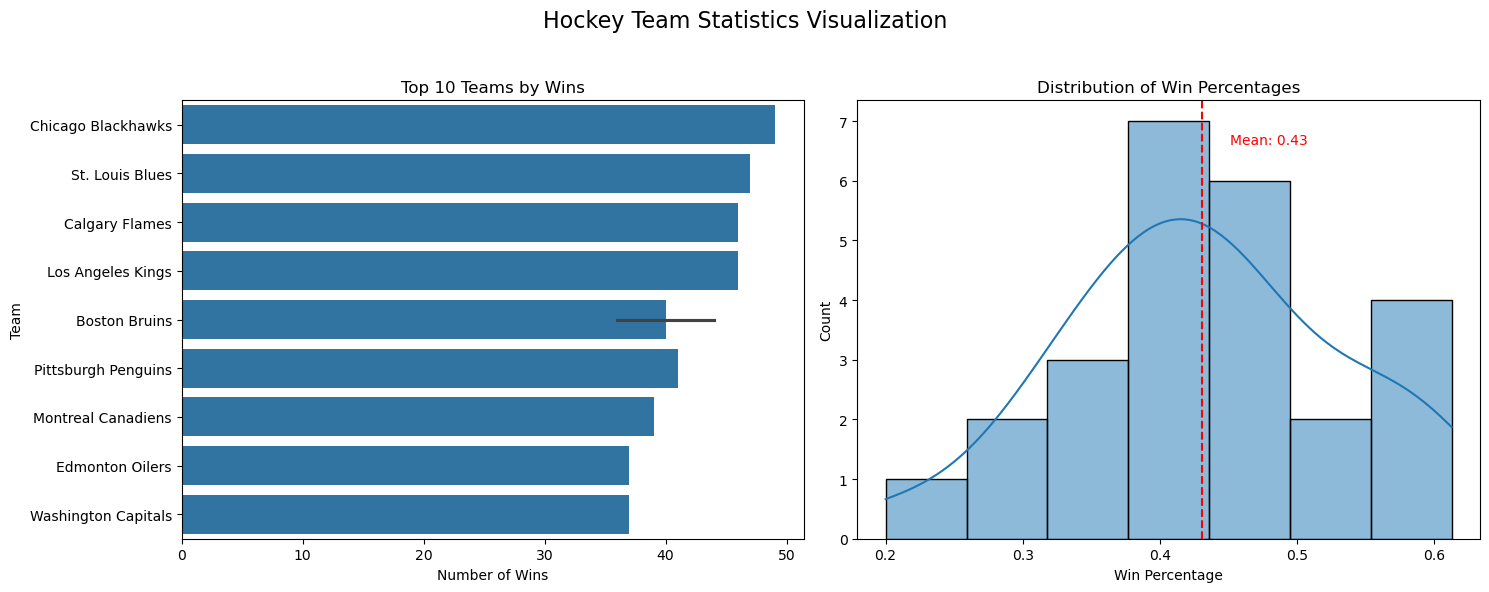

2025-05-19 13:56:49,173 - HockeyScraper - INFO - Successfully saved data to ./hockey_data/Hockey_Data_20250519_135649.csv
2025-05-19 13:56:49,175 - HockeyScraper - INFO - Inspected CSV file ./hockey_data/Hockey_Data_20250519_135649.csv: 25 rows, 11 columns
2025-05-19 13:56:49,176 - HockeyScraper - INFO - Workflow completed with status: True



Saving data to CSV...
Successfully saved data to ./hockey_data/Hockey_Data_20250519_135649.csv
   Rows: 25, Columns: 11
   File size: 2.12 KB

Verifying saved CSV file...

CSV FILE INSPECTION
File Path: ./hockey_data/Hockey_Data_20250519_135649.csv
File Size: 2.12 KB
Last Modified: 2025-05-19 13:56:49.173126
Number of Rows: 25
Number of Columns: 11

Column Names:
  1. Team Name
  2. Year
  3. Wins
  4. Losses
  5. OT Losses
  6. Win %
  7. Goals For (GF)
  8. Goals Against (GA)
  9. + / -
  10. Scraped_Date
  11. Win-Loss Ratio

First 10 rows:
+----+-----------------------+--------+--------+----------+-------------+---------+------------------+----------------------+---------+---------------------+------------------+
|    | Team Name             |   Year |   Wins |   Losses |   OT Losses |   Win % |   Goals For (GF) |   Goals Against (GA) |   + / - | Scraped_Date        |   Win-Loss Ratio |
+====+=======================+========+========+==========+=============+=========+============

In [13]:
def main() -> None:
    """
    Main function to initialize and run the hockey scraper.
    """
    # Print welcome message
    print("="*80)
    print("HOCKEY STANDINGS WEB SCRAPER")
    print("="*80)
    print("A tool for extracting, analyzing, and visualizing hockey team statistics")
    print("By: Amidu Dabor")
    print("Date: 18 May 2025")
    print("="*80)
    
    # URL for hockey standings - this example uses a website specifically designed for scraping practice
    url = 'https://www.scrapethissite.com/pages/forms/'
    
    # Output directory
    output_dir = "./hockey_data"
    
    try:
        # Create scraper instance with verbose output
        print(f"\nInitializing scraper for URL: {url}")
        print(f"Output directory: {output_dir}\n")
        
        scraper = HockeyScraper(url, output_dir=output_dir, verbose=True)
        
        # Run the complete workflow
        results = scraper.run_complete_workflow(save_visualizations=True)
        
        if results["success"]:
            print(f"\nHockey data extraction workflow completed successfully in {results['execution_time']:.2f} seconds! \nCSV data saved to: {results.get('csv_path', 
            'output directory')}.")
        
    except Exception as e:
        print(f"\nAn unexpected error occurred: {str(e)}")
        print("Please check the log file for more details.")

if __name__ == "__main__":
    main()